<a href="https://colab.research.google.com/github/Sumit05-Y/EDA-DATASCIENCE/blob/main/NEPSE(NABIL).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

nabil= pd.read_csv("NABILONEYEARCSV.csv")
nabil.shape
nabil.ndim
nabil.head()
nabil.tail()
nabil.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223 entries, 0 to 222
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Symbol          223 non-null    object 
 1   Date            223 non-null    object 
 2   Open            223 non-null    float64
 3   High            223 non-null    float64
 4   Low             223 non-null    float64
 5   Close           223 non-null    float64
 6   Percent Change  223 non-null    object 
 7   Volume          223 non-null    object 
 8   Turn Over       223 non-null    object 
dtypes: float64(4), object(5)
memory usage: 15.8+ KB


In [ ]:
import numpy as np
nabil["Date"] = pd.to_datetime(nabil["Date"]) #data typechanging

nabil["Volume"] = nabil["Volume"].replace("-",np.nan)
nabil["Volume"] = nabil["Volume"].str.replace("," ,"",regex=False).astype(float)


In [ ]:
nabil["Percent Change"]=nabil["Percent Change"].str.replace("%", '',regex=False).str.strip().astype(float)


In [ ]:
nabil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223 entries, 0 to 222
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Symbol          223 non-null    object        
 1   Date            223 non-null    datetime64[ns]
 2   Open            223 non-null    float64       
 3   High            223 non-null    float64       
 4   Low             223 non-null    float64       
 5   Close           223 non-null    float64       
 6   Percent Change  223 non-null    float64       
 7   Volume          223 non-null    float64       
 8   Turn Over       223 non-null    object        
dtypes: datetime64[ns](1), float64(6), object(2)
memory usage: 15.8+ KB


In [ ]:
nabil = nabil.drop(columns = ["Symbol","Turn Over"])

In [ ]:
nabil=nabil.sort_values("Date").reset_index(drop =True)
nabil.head()






,Date,Open,High,Low,Close,Percent Change,Volume
0,2025-07-07,500.0,503.0,496.3,497.07,-0.76,36175.0
1,2025-07-08,500.0,500.0,493.0,495.46,-0.32,33006.0
2,2025-07-09,500.0,500.0,495.2,499.01,0.72,42721.0
3,2025-07-10,503.0,522.0,500.0,511.17,2.44,264663.0
4,2025-07-13,521.3,537.5,521.3,535.77,4.81,270279.0


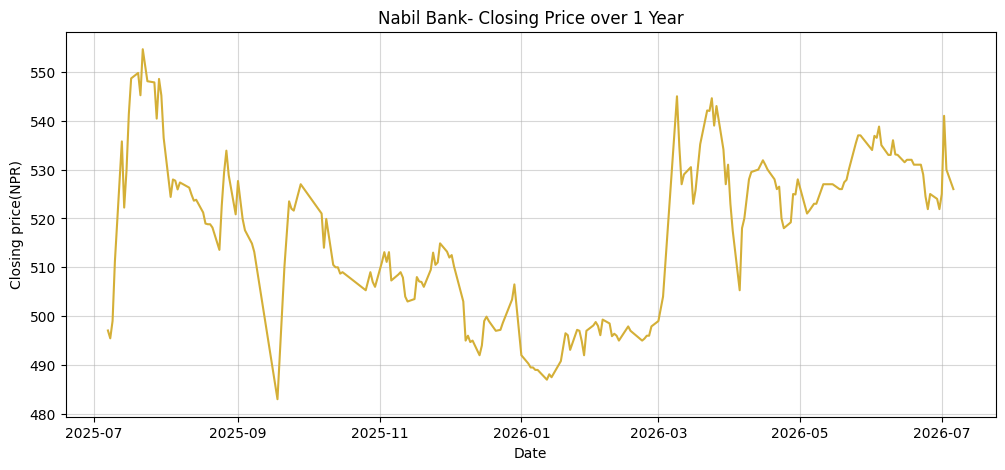

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(nabil["Date"], nabil['Close'], color="#D4AF37", linewidth=1.5)
plt.title("Nabil Bank- Closing Price over 1 Year")
plt.xlabel("Date")
plt.ylabel("Closing price(NPR)")
plt.grid(True , alpha =0.5)

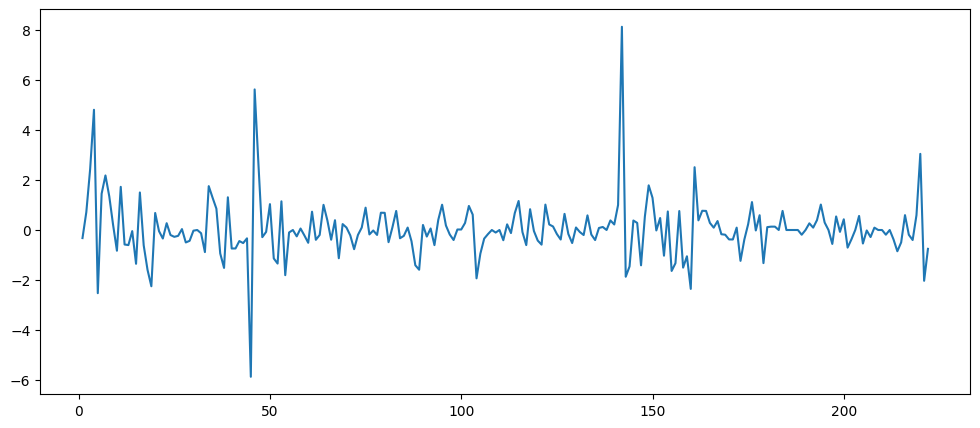

In [ ]:
nabil["Daily Return"] = nabil["Close"].pct_change() * 100
plt.figure(figsize=(12,5))
plt.plot(nabil["Daily Return"])

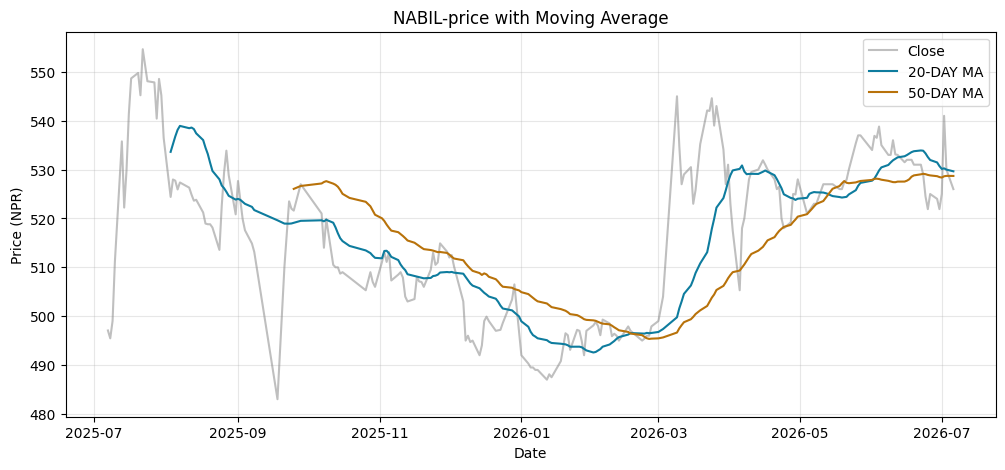

In [ ]:
nabil['MA20'] = nabil['Close'].rolling(window=20).mean()
nabil['MA50'] = nabil['Close'].rolling(window=50).mean()

plt.figure(figsize=(12,5))
plt.plot(nabil['Date'], nabil['Close'],label='Close',alpha=0.5, color='gray')
plt.plot(nabil['Date'], nabil['MA20'],label='20-DAY MA',color='#0E7C9E')
plt.plot(nabil['Date'], nabil['MA50'],label='50-DAY MA', color='#B8720A')
plt.title("NABIL-price with Moving Average")
plt.xlabel("Date")
plt.ylabel("Price (NPR)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

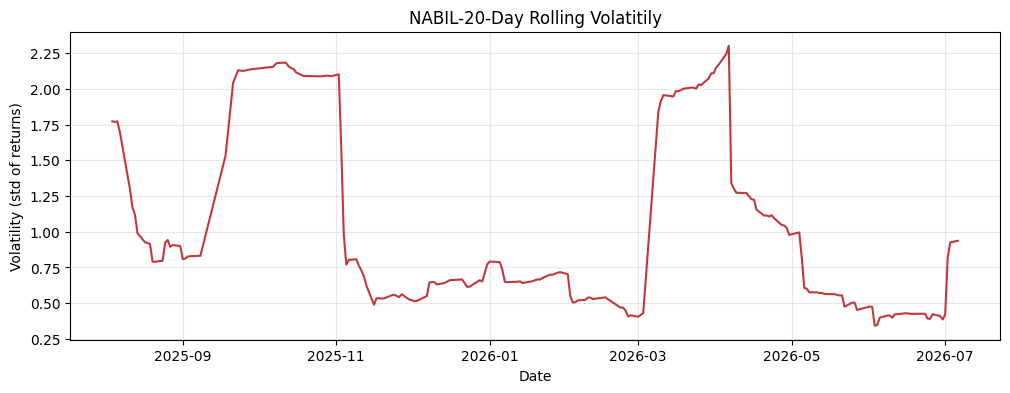

In [ ]:
nabil['Volatility'] = nabil["Daily Return"].rolling(window=20).std()

plt.figure(figsize=(12,4))
plt.plot(nabil["Date"],nabil['Volatility'], color ="#C13A3A")
plt.title("NABIL-20-Day Rolling Volatitily")
plt.xlabel("Date")
plt.ylabel("Volatility (std of returns)")
plt.grid(True,alpha=0.3)
plt.show()